# Kaggle - Binary Prediction of Poisonous Mushrooms

## Competition Context
This competition is part of the Tabular Playground Series (S4E8).
The goal is to predict the class of a mushroom from its physical characteristics.

## Prediction Objective
For each observation in the test set, we want to predict the target variable `class`:
- `e`: edible
- `p`: poisonous

This is a **binary classification** problem.

## Dataset Analysis

In this section, we aim to understand the structure and quality of the dataset before modeling.

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

ROOT = Path.cwd()
if not (ROOT / "data" / "train.csv").exists():
    ROOT = ROOT.parent

train_path = ROOT / "data" / "train.csv"
test_path = ROOT / "data" / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
print(f"Train file  : {train_path}")
print(f"Test file   : {test_path}")

Train shape: (3116945, 22)
Test shape : (2077964, 21)
Train file  : c:\Users\alexi\Documents\Alexis\UTBM\Branche_A2\DS52 statistics\TP\Projet\mushroom-prediction\data\train.csv
Test file   : c:\Users\alexi\Documents\Alexis\UTBM\Branche_A2\DS52 statistics\TP\Projet\mushroom-prediction\data\test.csv


The train set has 3 116 945 entries, and 22 features (including the label)

The test set has 2 077 964 entries, and 21 features

In [3]:
train_df.head()

,id,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,0,e,8.80,f,s,u,f,a,c,w,4.51,15.39,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
1,1,p,4.51,x,h,o,f,a,c,n,4.79,6.48,NaN,y,o,NaN,NaN,t,z,NaN,d,w
2,2,e,6.94,f,s,b,f,x,c,w,6.85,9.93,NaN,s,n,NaN,NaN,f,f,NaN,l,w
3,3,e,3.88,f,y,g,f,s,NaN,g,4.16,6.53,NaN,NaN,w,NaN,NaN,f,f,NaN,d,u
4,4,e,5.85,x,l,w,f,d,NaN,w,3.37,8.36,NaN,NaN,w,NaN,NaN,f,f,NaN,g,a


By looking at the first few rows of the train dataset, wd can see what it looks like.

We notice that some columns already have NaN values on these first few rows. 

## 1) Data Inventory

Questions to answer:
- How many rows and columns are in train and test?
- Which columns are categorical, numerical, or mixed?
- Is there any identifier column that should not be used as a feature?


In [4]:
train_feature_cols = [c for c in train_df.columns if c != "class"]

def describe_columns(df: pd.DataFrame, name: str) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append(
            {
                "dataset": name,
                "column": col,
                "dtype": str(s.dtype),
                "n_unique": s.nunique(dropna=True),
                "missing_pct": round(s.isna().mean() * 100, 2),
                "kind": (
                    "identifier" if col.lower() == "id"
                    else "target" if col == "class"
                    else "categorical" if s.dtype == "object"
                    else "numeric"
                ),
            }
        )
    return pd.DataFrame(rows)

inventory = pd.concat(
    [describe_columns(train_df, "train"), describe_columns(test_df, "test")],
    ignore_index=True,
)

shape_summary = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train_df), len(test_df)],
        "columns": [train_df.shape[1], test_df.shape[1]],
    }
)

print("Dataset shape summary:")
display(shape_summary)

print("Column-level inventory (first 20 rows):")
display(inventory.head(20))

print("Feature dtype distribution (train, excluding target):")
display(train_df[train_feature_cols].dtypes.value_counts().rename_axis("dtype").reset_index(name="count"))

Dataset shape summary:


,dataset,rows,columns
0,train,3116945,22
1,test,2077964,21


Column-level inventory (first 20 rows):


,dataset,column,dtype,n_unique,missing_pct,kind
0,train,id,int64,3116945,0.00,identifier
1,train,class,str,2,0.00,target
2,train,cap-diameter,float64,3913,0.00,numeric
3,train,cap-shape,str,74,0.00,numeric
4,train,cap-surface,str,83,21.53,numeric
5,train,cap-color,str,78,0.00,numeric
6,train,does-bruise-or-bleed,str,26,0.00,numeric
7,train,gill-attachment,str,78,16.81,numeric
8,train,gill-spacing,str,48,40.37,numeric
9,train,gill-color,str,63,0.00,numeric


Feature dtype distribution (train, excluding target):


,dtype,count
0,str,17
1,float64,3
2,int64,1


### Interpretation

We use this output to answer these questions:
- What is the role of each column (identifier, target, categorical, numerical)?
- Are there obvious data quality risks (high missing rate, unusual type)?
- Which transformations will be required before modeling?

We have a lot of columns that have a type string, and only a few with floats and integers.

Some columns are missing a lot of values, and need to be handled properly in consequence :


veil-type - 94.88% of missing values

spore-print-color - 91.43%

stem-root - 88.45%

veil-color - 87.94%

stem-surface - 63.55%

gill-spacing - 40.37%

cap-surface - 21.53%

gill-attachment - 16.81%

ring-type - 4.13%


We also have many features that have many unique values

If we look at the feature veil-type in detail, here is what it looks like :

In [5]:
print("Unique values for 'veil-type' column:")
display(train_df['veil-type'].value_counts(dropna=False).to_frame())

Unique values for 'veil-type' column:


,count
veil-type,
NaN,2957493
u,159373
w,11
a,9
e,8
f,8
c,5
b,5
g,4


We have a majority of NaN values, followed by a large number of "u" values. The other values are present only with a few instances, making us believe there might be outliers here. The numbers are obviously outliers

Many of the categorical features have many unique values. We also need to check if it is right. For example, the feature cap-surface with 83 uniques values : 

In [6]:
print("Unique values for 'cap-surface' column:")
display(train_df['cap-surface'].value_counts(dropna=False).to_frame())

Unique values for 'cap-surface' column:


,count
cap-surface,
NaN,671023
t,460777
s,384970
y,327826
h,284460
g,263729
d,206832
k,128875
e,119712


This feature needs some analysis to see what is right or not. Indeed, we have a lot of different values : Many NaN values, followed by letters. Then there are some values that are the names of other features, which seems wrong, as well as numbers, which also seems wrong

## 2) Target Variable Analysis (`class`)

Questions to answer:
- Is the target balanced or imbalanced?
- What is the proportion of `e` vs `p`?

,count,percent
class,,
p,1705396,54.71
e,1411549,45.29


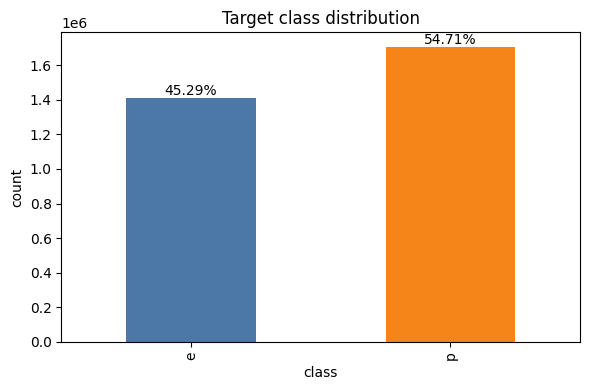

Imbalance ratio (majority/minority): 1.208


In [7]:
if "class" not in train_df.columns:
    raise ValueError("Column 'class' was not found in train.csv")

target_counts = train_df["class"].value_counts(dropna=False)
target_pct = train_df["class"].value_counts(normalize=True, dropna=False).mul(100).round(2)

target_summary = pd.DataFrame({"count": target_counts, "percent": target_pct})
display(target_summary)

ax = target_counts.sort_index().plot(kind="bar", figsize=(6, 4), color=["#4C78A8", "#F58518"])
ax.set_title("Target class distribution")
ax.set_xlabel("class")
ax.set_ylabel("count")

for i, (label, value) in enumerate(target_counts.sort_index().items()):
    pct = target_pct[label]
    ax.text(i, value, f"{pct}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

balance_ratio = target_counts.max() / target_counts.min()
print(f"Imbalance ratio (majority/minority): {balance_ratio:.3f}")

### Interpretation :
We have a small difference distribution between the two classes. For the moment, we decide to stay with this proportion. But it can be an idea to adjust this proportion to improve the future model.

## 3) Missing Values and Data Quality

Questions to answer:
- Which columns contain missing values?
- What is the missing rate per column?
- Are there suspicious categories (typos, rare values, inconsistent labels)?

Columns with missing values: 18


,missing_pct_train,missing_pct_test,missing_diff_pp
cap-color,0.000385,0.000626,-0.000241
cap-diameter,0.000128,0.000337,-0.000209
cap-shape,0.001283,0.001492,-0.000209
cap-surface,21.528227,21.506821,0.021406
does-bruise-or-bleed,0.000257,0.000481,-0.000225
gill-attachment,16.809280,16.834796,-0.025516
gill-color,0.001829,0.002358,-0.000529
gill-spacing,40.373988,40.404694,-0.030706
habitat,0.001444,0.001203,0.000241
has-ring,0.000770,0.000914,-0.000144


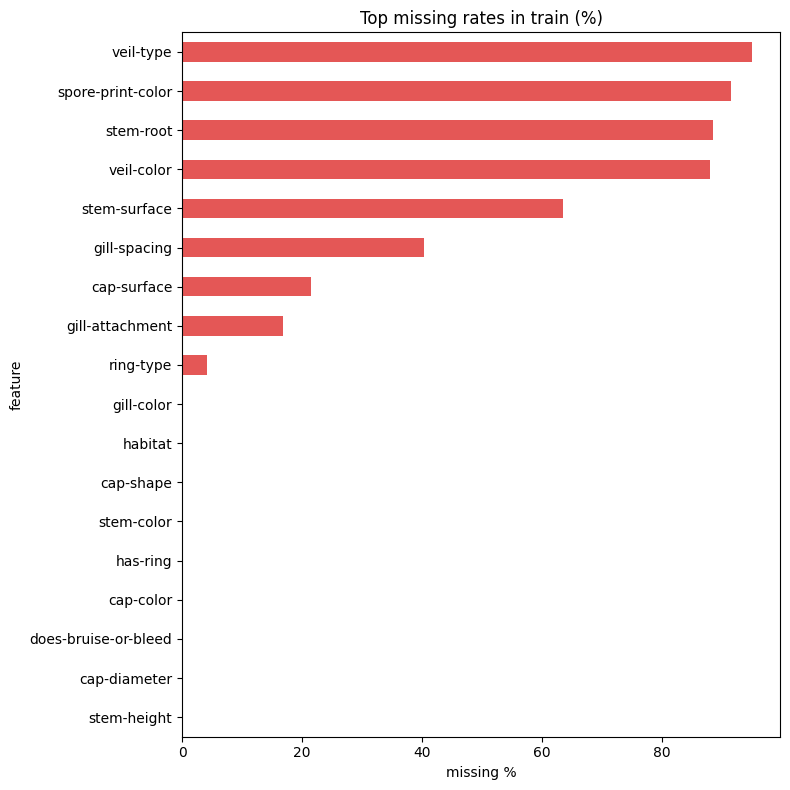

In [8]:
missing_train = train_df.isna().mean().mul(100).sort_values(ascending=False)
missing_test = test_df.isna().mean().mul(100).sort_values(ascending=False)

missing_report = pd.DataFrame(
    {
        "missing_pct_train": missing_train,
        "missing_pct_test": missing_test,
    }
).fillna(0.0)
missing_report["missing_diff_pp"] = missing_report["missing_pct_train"] - missing_report["missing_pct_test"]
missing_report = missing_report[["missing_pct_train", "missing_pct_test", "missing_diff_pp"]]

missing_non_zero = missing_report[(missing_report["missing_pct_train"] > 0) | (missing_report["missing_pct_test"] > 0)]
print(f"Columns with missing values: {len(missing_non_zero)}")
display(missing_non_zero.head(30))

if not missing_non_zero.empty:
    top_missing = missing_non_zero.sort_values("missing_pct_train", ascending=True).tail(25)
    ax = top_missing["missing_pct_train"].plot(kind="barh", figsize=(8, 8), color="#E45756")
    ax.set_title("Top missing rates in train (%)")
    ax.set_xlabel("missing %")
    ax.set_ylabel("feature")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected in train/test.")

### Missing values and quality

Two key signals matter here:
- absolute missing rates per feature,
- similarity of missing rates between train and test.

If missingness is similar across train and test, preprocessing learned on train is more likely to transfer safely to test.

In [9]:
cat_cols = train_df.select_dtypes(include=["object", "string"]).columns.tolist()
cat_cols = [c for c in cat_cols if c != "class"]

rare_threshold = 0.005  # 0.5%
rare_rows = []

for col in cat_cols:
    freq = train_df[col].value_counts(normalize=True, dropna=False)
    rare = freq[freq < rare_threshold]
    rare_rows.append(
        {
            "column": col,
            "n_unique": train_df[col].nunique(dropna=True),
            "n_rare_categories": int(rare.shape[0]),
            "rare_total_pct": round(float(rare.sum() * 100), 3),
        }
    )

rare_summary = pd.DataFrame(rare_rows).sort_values(
    ["n_rare_categories", "rare_total_pct"], ascending=False
)
display(rare_summary.head(20))

,column,n_unique,n_rare_categories,rare_total_pct
1,cap-surface,83,72,0.019
4,gill-attachment,78,71,0.016
0,cap-shape,74,68,0.018
2,cap-color,78,67,0.012
8,stem-surface,60,53,0.029
6,gill-color,63,52,0.016
9,stem-color,59,50,0.585
15,habitat,52,46,0.185
5,gill-spacing,48,45,0.005
7,stem-root,38,34,0.025


This step identifies high-cardinality categorical features and quantifies how many levels are rare.

Why this matters:
- rare levels increase overfitting risk,
- they make one-hot encoding unstable,
- and they amplify train/test mismatch.

Grouping rare levels into one label is a regularization strategy for categorical variables.

## 4) Train vs Test Consistency Check

Questions to answer:
- Do train and test share the same columns and category space?
- Are there categories present in test but absent in train?


In [10]:
train_cols = set(train_df.columns)
test_cols = set(test_df.columns)

missing_in_test = sorted(train_cols - test_cols - {"class"})
extra_in_test = sorted(test_cols - train_cols)

print("Columns in train but not in test (excluding target):", missing_in_test)
print("Columns in test but not in train:", extra_in_test)

common_cat_cols = [
    c for c in train_df.select_dtypes(include=["object", "string"]).columns
    if c in test_df.columns and c != "class"
]

unseen_rows = []
for col in common_cat_cols:
    train_cats = set(train_df[col].dropna().unique())
    test_cats = set(test_df[col].dropna().unique())
    unseen_in_test = test_cats - train_cats
    unseen_rows.append(
        {
            "column": col,
            "train_unique": len(train_cats),
            "test_unique": len(test_cats),
            "unseen_in_test_count": len(unseen_in_test),
            "sample_unseen_in_test": ", ".join(list(sorted(unseen_in_test))[:5]) if unseen_in_test else "",
        }
    )

unseen_report = pd.DataFrame(unseen_rows).sort_values("unseen_in_test_count", ascending=False)
display(unseen_report.head(30))

n_problem_cols = (unseen_report["unseen_in_test_count"] > 0).sum()
print(f"Categorical columns with unseen categories in test: {n_problem_cols}")

Columns in train but not in test (excluding target): []
Columns in test but not in train: []


,column,train_unique,test_unique,unseen_in_test_count,sample_unseen_in_test
4,gill-attachment,78,66,39,"0.87, 0.88, 0.93, 0.95, 1.26"
0,cap-shape,74,62,34,"0.74, 0.93, 0.97, 1.25, 1.53"
1,cap-surface,83,59,31,"0.94, 1.95, 10.09, 11.96, 12.15"
2,cap-color,78,57,31,"0.73, 0.91, 1.83, 10.83, 10.93"
9,stem-color,59,55,29,"10.6, 10.93, 11.0, 11.31, 17.16"
8,stem-surface,60,54,27,"10.14, 11.53, 13.01, 13.09, 15.25"
6,gill-color,63,56,23,"1.55, 10.34, 10.56, 12.87, 17.26"
5,gill-spacing,48,35,18,"1.46, 1.61, 1.64, 1.68, 13.66"
15,habitat,52,39,13,"1.75, 19.85, 2.02, 2.53, 3.19"
14,spore-print-color,32,33,11,"17.72, 2.52, 2.92, 26.48, 27.48"


Categorical columns with unseen categories in test: 16


### Train vs test consistency

We verify:
- feature alignment between train and test,
- and unseen categories appearing only in test.

If unseen categories are frequent, our encoder must ignore unknown levels (or map them beforehand).

## 5) End-of-Analysis Summary

### Key findings
- The dataset is large: about 3.12M rows in train and 2.08M rows in test, which supports robust cross-validation.
- The target is mildly imbalanced (`p`: 54.71%, `e`: 45.29%; imbalance ratio ~1.21).
- Several features have very high missing rates (up to ~95%), especially `veil-type`, `spore-print-color`, `stem-root`, and `veil-color`.
- Missing-value rates are very similar in train and test, which reduces distribution-shift risk on this aspect.
- Many categorical features contain categories in test that are not present in train (16 columns affected), so encoding must safely handle unseen levels.

### Preprocessing strategy
- Keep rows and handle missing values explicitly (`MISSING` for categorical features, KNN imputation for numerical features).
- Use an encoding/modeling pipeline that is robust to unknown categories at inference time.


## Feature Treatment Plan

This table summarizes what to do with each feature before modeling. The key idea is to treat each column according to its statistical role, not all in the same way.

| Column | Type | Main issue | Recommended action | Encoder / Imputer | Why |
|---|---|---:|---|---|---|
| `id` | Identifier | Unique per row | Drop | None | It does not carry predictive information. |
| `class` | Target | Prediction label | Keep as target only | None | This is the label to predict. |
| `cap-diameter` | Numeric | No missing values, continuous values | Keep | KNN | Stable numeric feature, robust to outliers. |
| `stem-height` | Numeric | No missing values, continuous values | Keep | KNN | Stable numeric feature, robust to outliers. |
| `stem-width` | Numeric | No missing values, continuous values | Keep | KNN | Stable numeric feature, robust to outliers. |
| `season` | Categorical, low cardinality | Few categories | Keep | OneHotEncoder | Small number of levels, easy to encode. |
| `does-bruise-or-bleed` | Categorical, low cardinality | Binary / small cardinality | Keep | OneHotEncoder | Very compact and informative. |
| `has-ring` | Categorical, low cardinality | Binary / small cardinality | Keep | OneHotEncoder | Very compact and informative. |
| `cap-shape` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | Prevents overfitting on tiny categories. |
| `cap-surface` | Categorical, high cardinality | Many missing/rare modalities | Keep and group rare levels | OneHotEncoder  | Useful signal, but too fragmented as-is. |
| `cap-color` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | Color remains informative after rare grouping. |
| `gill-attachment` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | Strong candidate for rare-category compression. |
| `gill-spacing` | Categorical, high cardinality | Many missing and rare modalities | Keep and group rare levels | OneHotEncoder | Missingness itself may be informative. |
| `gill-color` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | High-cardinality feature, do not drop blindly. |
| `stem-root` | Categorical, very high missing rate | Almost always missing | Keep in first baseline, test dropping in ablation | Missing -> `MISSING`, rare -> `RARE` | The missing pattern may carry signal. |
| `stem-surface` | Categorical, very high missing rate | Almost always missing | Keep in first baseline, test dropping in ablation | Missing -> `MISSING`, rare -> `RARE` | Sparse but possibly informative. |
| `stem-color` | Categorical, high cardinality | Many rare modalities | Keep and group rare levels | OneHotEncoder | Useful after rare-category grouping. |
| `veil-type` | Categorical, extremely high missing rate | Near-constant missingness | Keep only as an experiment | Missing -> `MISSING`, rare -> `RARE` | Often weak, but keep for a controlled comparison. |
| `veil-color` | Categorical, extremely high missing rate | Near-constant missingness | Keep only as an experiment | Missing -> `MISSING`, rare -> `RARE` | The missing pattern may be more useful than the raw value. |
| `ring-type` | Categorical, moderate cardinality | Some rare modalities | Keep and group rare levels | OneHotEncoder | Moderate cardinality, still informative. |
| `habitat` | Categorical, moderate cardinality | Rare categories exist | Keep and group rare levels | OneHotEncoder | Often useful biologically. |

### Practical interpretation
- `MISSING` means the value was absent in the original data.
- `RARE` means the value existed but was too infrequent to be trusted alone.
- The current pipeline in this notebook is: keep categorical missingness explicit, group rare categories, impute numerical values with KNN, then apply one-hot encoding.


## Data cleaning

In [11]:
train_df_cleaned = train_df.copy()
test_df_cleaned = test_df.copy()

### 1) Delete id column

In [12]:
train_df_cleaned = train_df_cleaned.drop(columns=['id'])
test_df_cleaned = test_df_cleaned.drop(columns=['id'])

print(train_df_cleaned.shape)
print(test_df_cleaned.shape)

(3116945, 21)
(2077964, 20)


### 2) Setup cleaning objects

In [13]:

TARGET_COL = "class"
RARE_LABEL = "RARE"
MISSING_LABEL = "MISSING"
RARE_THRESHOLD = 0.005  # 0.5%

# Partir des copies déjà créées
# train_df_cleaned / test_df_cleaned
X_train = train_df_cleaned.drop(columns=[TARGET_COL], errors="ignore").copy()
y_train = train_df_cleaned[TARGET_COL].copy()
X_test = test_df_cleaned.copy()

# Colonnes catégorielles / numériques
categorical_cols = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["number"]).columns.tolist()

print("Target:", TARGET_COL)
print("N categorical:", len(categorical_cols))
print("N numerical:", len(numerical_cols))
print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Target: class
N categorical: 17
N numerical: 3
Categorical columns: ['cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']
Numerical columns: ['cap-diameter', 'stem-height', 'stem-width']


### 3) Group together rare categories

In [14]:
rare_maps = {}

for col in categorical_cols:
    freq = X_train[col].value_counts(normalize=True, dropna=True)
    rare_values = freq[freq < RARE_THRESHOLD].index
    rare_maps[col] = set(rare_values)

print("Example rare counts per column:")
display(
    pd.Series({c: len(v) for c, v in rare_maps.items()})
    .sort_values(ascending=False)
    .to_frame("n_rare_categories")
    .head(20)
)

Example rare counts per column:


,n_rare_categories
cap-surface,72
gill-attachment,71
cap-shape,67
cap-color,66
stem-surface,53
gill-color,51
stem-color,49
habitat,45
gill-spacing,45
stem-root,34


### 4) Apply mapping train/test + handle unknowns and NaN 

In [15]:
for col in categorical_cols:
    # Convertir en string pour éviter les surprises de dtype
    X_train[col] = X_train[col].astype("string")
    X_test[col] = X_test[col].astype("string")

    # NaN explicite
    X_train[col] = X_train[col].fillna(MISSING_LABEL)
    X_test[col] = X_test[col].fillna(MISSING_LABEL)

    # Regrouper les rares du train
    X_train[col] = X_train[col].where(~X_train[col].isin(rare_maps[col]), RARE_LABEL)

    # Côté test:
    # - valeurs rares connues -> RARE
    # - valeurs inconnues (pas vues dans train) -> RARE aussi
    known_train_values = set(X_train[col].unique())
    X_test[col] = X_test[col].where(X_test[col].isin(known_train_values), RARE_LABEL)

### 5) Numeric imputation

In [16]:
from sklearn.impute import KNNImputer

knn_imputer = KNNImputer(n_neighbors=5, weights="distance")
X_train[numerical_cols] = knn_imputer.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = knn_imputer.transform(X_test[numerical_cols])

### 6) Checks

In [17]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("Remaining NaN train:", int(X_train.isna().sum().sum()))
print("Remaining NaN test :", int(X_test.isna().sum().sum()))

# Vérifier rapidement cardinalité post-nettoyage
post_card = pd.Series({c: X_train[c].nunique(dropna=False) for c in categorical_cols}) \
    .sort_values(ascending=False) \
    .to_frame("n_unique_after_cleaning")
display(post_card.head(20))

X_train shape: (3116945, 20)
X_test shape : (2077964, 20)
Remaining NaN train: 0
Remaining NaN test : 0


,n_unique_after_cleaning
cap-color,14
gill-color,14
cap-surface,13
stem-color,12
cap-shape,9
stem-surface,9
spore-print-color,9
habitat,9
gill-attachment,9
ring-type,9


In [18]:
# Display the cleaned tables and a few useful summaries
display(X_train.head())
display(X_test.head())

print('Cleaned train info:')
display(pd.DataFrame({
    'rows': [X_train.shape[0]],
    'columns': [X_train.shape[1]],
    'missing_total': [int(X_train.isna().sum().sum())],
    'categorical_cols': [len(categorical_cols)],
    'numerical_cols': [len(numerical_cols)],
}))

print('Cleaned test info:')
display(pd.DataFrame({
    'rows': [X_test.shape[0]],
    'columns': [X_test.shape[1]],
    'missing_total': [int(X_test.isna().sum().sum())],
}))

,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,8.80,f,s,u,f,a,c,w,4.51,15.39,MISSING,MISSING,w,MISSING,MISSING,f,f,MISSING,d,a
1,4.51,x,h,o,f,a,c,n,4.79,6.48,MISSING,y,o,MISSING,MISSING,t,z,MISSING,d,w
2,6.94,f,s,b,f,x,c,w,6.85,9.93,MISSING,s,n,MISSING,MISSING,f,f,MISSING,l,w
3,3.88,f,y,g,f,s,MISSING,g,4.16,6.53,MISSING,MISSING,w,MISSING,MISSING,f,f,MISSING,d,u
4,5.85,x,l,w,f,d,MISSING,w,3.37,8.36,MISSING,MISSING,w,MISSING,MISSING,f,f,MISSING,g,a


,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,8.64,x,MISSING,n,t,MISSING,MISSING,w,11.13,17.12,b,MISSING,w,u,w,t,g,MISSING,d,a
1,6.90,o,t,o,f,MISSING,c,y,1.27,10.75,MISSING,MISSING,n,MISSING,MISSING,f,f,MISSING,d,a
2,2.00,b,g,n,f,MISSING,c,n,6.18,3.14,MISSING,MISSING,n,MISSING,MISSING,f,f,MISSING,d,s
3,3.47,x,t,n,f,s,c,n,4.98,8.51,MISSING,MISSING,w,MISSING,n,t,z,MISSING,d,u
4,6.17,x,h,y,f,p,MISSING,y,6.73,13.70,MISSING,MISSING,y,MISSING,y,t,MISSING,MISSING,d,u


Cleaned train info:


,rows,columns,missing_total,categorical_cols,numerical_cols
0,3116945,20,0,17,3


Cleaned test info:


,rows,columns,missing_total
0,2077964,20,0


### 7) One-Hot Encoding (after cleaning)

At this stage, categorical features are cleaned (`MISSING` and `RARE` already handled), and numerical features are imputed.

We now apply One-Hot Encoding on categorical columns only, keep numerical columns as they are, and concatenate both into sparse matrices suitable for modeling on large datasets.

In [19]:
from sklearn.preprocessing import OneHotEncoder
from scipy import sparse
import numpy as np

# One-hot encode categorical columns
ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True,
    dtype=np.float32
)

X_train_cat = ohe.fit_transform(X_train[categorical_cols])
X_test_cat = ohe.transform(X_test[categorical_cols])

# Keep numerical columns as sparse matrices
X_train_num = sparse.csr_matrix(X_train[numerical_cols].to_numpy(dtype=np.float32))
X_test_num = sparse.csr_matrix(X_test[numerical_cols].to_numpy(dtype=np.float32))

# Final design matrices for modeling
X_train_final = sparse.hstack([X_train_num, X_train_cat], format="csr")
X_test_final = sparse.hstack([X_test_num, X_test_cat], format="csr")

print("X_train_final shape:", X_train_final.shape)
print("X_test_final shape :", X_test_final.shape)
print("Train nnz:", X_train_final.nnz)
print("Test nnz :", X_test_final.nnz)

# Quick feature-name check
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + ohe_feature_names.tolist()
print("Total encoded feature count:", len(all_feature_names))
print("First 20 feature names:")
print(all_feature_names[:20])

X_train_final shape: (3116945, 144)
X_test_final shape : (2077964, 144)
Train nnz: 62337849
Test nnz : 41558621
Total encoded feature count: 144
First 20 feature names:
['cap-diameter', 'stem-height', 'stem-width', 'cap-shape_MISSING', 'cap-shape_RARE', 'cap-shape_b', 'cap-shape_c', 'cap-shape_f', 'cap-shape_o', 'cap-shape_p', 'cap-shape_s', 'cap-shape_x', 'cap-surface_MISSING', 'cap-surface_RARE', 'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h', 'cap-surface_i', 'cap-surface_k']


### Reading guide - One-hot encoded matrices

After encoding, always verify:
- final matrix dimensions,
- sparsity (nnz) to estimate memory usage,
- and feature name expansion.

A very large feature count is normal with one-hot encoding on high-cardinality columns; sparsity keeps computation tractable.

## Models

### Logistic Regression

First we use Logistic Regression

In [20]:
"""
# ============================================================
# LOGISTIC REGRESSION - BASELINE MODEL
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef
)

# ============================================================
# STEP 1: TRAIN/VALIDATION SPLIT
# ============================================================
# We NEVER evaluate on training data (causes overfitting)
# Instead: split into 80% train (to learn), 20% validation (to test fairly)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final,
    y_train,
    test_size=0.2,           # 20% validation data
    random_state=42,         # Reproducible split
    stratify=y_train         # Keep class distribution balanced
)

print(f"Train set: {X_tr.shape[0]:,} rows")
print(f"Validation set: {X_val.shape[0]:,} rows")

# ============================================================
# STEP 2: TRAIN LOGISTIC REGRESSION
# ============================================================
# Logistic regression = linear model for binary classification
# Output = probability between 0 and 1

model = LogisticRegression(
    max_iter=200,           # Max iterations (usually 100, but play it safe)
    solver="saga",          # SAGA solver: fast on large sparse data
    verbose=1               # Print progress messages
)

print("\n" + "="*50)
print("Training Logistic Regression...")
print("="*50)
model.fit(X_tr, y_tr)

# ============================================================
# STEP 3: MAKE PREDICTIONS ON VALIDATION SET
# ============================================================
y_pred = model.predict(X_val)               # Class predictions (e or p)
y_proba = model.predict_proba(X_val)[:, 1]  # Probability of class "p"

# ============================================================
# STEP 4: CONFUSION MATRIX
# ============================================================
# Shows: True Positives, True Negatives, False Positives, False Negatives

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# STEP 5: EVALUATE METRICS
# ============================================================
print("\n" + "="*50)
print("LOGISTIC REGRESSION - VALIDATION RESULTS")
print("="*50)

# Classification report: precision, recall, f1-score
print(classification_report(y_val, y_pred))

# Matthews Correlation Coefficient (good for imbalanced data)
mcc = matthews_corrcoef(y_val, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

# ROC-AUC: area under ROC curve (0.5=random, 1.0=perfect)
roc_auc = roc_auc_score(y_val, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("  → 0.5 = Random classifier")
print("  → 0.9+ = Excellent classifier")

# ============================================================
# STEP 6: ROC CURVE
# ============================================================
# Shows trade-off between true positive rate and false positive rate

fpr, tpr, _ = roc_curve(y_val, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression - Validation ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 7: PREPARE KAGGLE SUBMISSION
# ============================================================
# Predict on FULL test set using trained model

test_pred = model.predict(X_test_final)
submission = pd.DataFrame({
    "id": test_df["id"],
    "class": test_pred
})

print(f"\nSubmission file preview:")
display(submission.head(10))
print(f"Total predictions: {len(submission)}")
print(f"Class distribution in predictions:")
print(submission["class"].value_counts())
"""

'\n# ============================================================\n# LOGISTIC REGRESSION - BASELINE MODEL\n# ============================================================\n\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.model_selection import train_test_split\nfrom sklearn.metrics import (\n    confusion_matrix,\n    classification_report,\n    roc_curve,\n    roc_auc_score,\n    matthews_corrcoef\n)\n\n# ============================================================\n# STEP 1: TRAIN/VALIDATION SPLIT\n# ============================================================\n# We NEVER evaluate on training data (causes overfitting)\n# Instead: split into 80% train (to learn), 20% validation (to test fairly)\n\nX_tr, X_val, y_tr, y_val = train_test_split(\n    X_train_final,\n    y_train,\n    test_size=0.2,           # 20% validation data\n    random_state=42,         # Reproducible split\n    stratify=y_train         # Keep class distribution balanced\n)\n\nprint(f"Train set: {X

### Logistic Regression - Results

With Logistic Regression, we get the following results :

### Random Forest

Next we use Random Forest

Train set: 2,493,556 rows
Validation set: 623,389 rows

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  3.4min finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.7s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done  50 out of  50 | elapsed:    0.7s finished


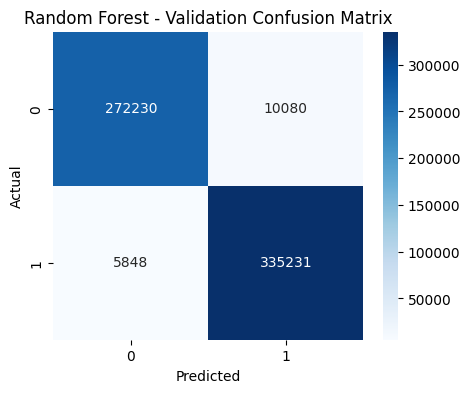


RANDOM FOREST - VALIDATION RESULTS
              precision    recall  f1-score   support

           e       0.98      0.96      0.97    282310
           p       0.97      0.98      0.98    341079

    accuracy                           0.97    623389
   macro avg       0.97      0.97      0.97    623389
weighted avg       0.97      0.97      0.97    623389

Matthews Correlation Coefficient (MCC): 0.9485
ROC-AUC Score: 0.9947


ValueError: y_true takes value in {'e', 'p'} and pos_label is not specified: either make y_true take value in {0, 1} or {-1, 1} or pass pos_label explicitly.

In [24]:
# ============================================================
# RANDOM FOREST - BASELINE MODEL
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef
)

# ============================================================
# STEP 1: TRAIN/VALIDATION SPLIT
# ============================================================

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_final,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print(f"Train set: {X_tr.shape[0]:,} rows")
print(f"Validation set: {X_val.shape[0]:,} rows")

# ============================================================
# STEP 2: TRAIN RANDOM FOREST
# ============================================================

model = RandomForestClassifier(
    n_estimators=50,         # Reduced from 200 to 50 for faster training
    max_depth=10,            # Limited depth to prevent overfitting and speed up
    min_samples_split=10,    # Increased to make trees smaller/faster
    min_samples_leaf=5,      # Increased to reduce complexity
    max_features="sqrt",     # Standard for classification
    n_jobs=-1,               # Use all CPU cores
    random_state=42,
    verbose=1
)

print("\n" + "="*50)
print("Training Random Forest...")
print("="*50)
model.fit(X_tr, y_tr)

# ============================================================
# STEP 3: MAKE PREDICTIONS ON VALIDATION SET
# ============================================================

y_pred = model.predict(X_val)
y_proba = model.predict_proba(X_val)[:, 1]

# ============================================================
# STEP 4: CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ============================================================
# STEP 5: EVALUATE METRICS
# ============================================================

print("\n" + "="*50)
print("RANDOM FOREST - VALIDATION RESULTS")
print("="*50)

print(classification_report(y_val, y_pred, labels=["e", "p"]))

mcc = matthews_corrcoef(y_val, y_pred)
print(f"Matthews Correlation Coefficient (MCC): {mcc:.4f}")

roc_auc = roc_auc_score(y_val, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ============================================================
# STEP 6: ROC CURVE
# ============================================================

fpr, tpr, _ = roc_curve(y_val, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - Validation ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 7: PREPARE KAGGLE SUBMISSION
# ============================================================

test_pred = model.predict(X_test_final)

submission = pd.DataFrame({
    "id": test_df["id"],
    "class": test_pred
})

print(f"\nSubmission file preview:")
display(submission.head(10))
print(f"Total predictions: {len(submission)}")
print(f"Class distribution in predictions:")
print(submission["class"].value_counts())

### Random Forest - Results

With Random Forest, we get the following results :

## XGBoost

In [23]:
# ============================================================
# XGBOOST - GRADIENT BOOSTING BASELINE (Manual Parameters)
# ============================================================
# XGBoost trains multiple trees sequentially, each correcting previous errors

import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef,
)

# ============================================================
# STEP 1: CONVERT TARGET TO NUMERIC
# ============================================================
# XGBoost requires numeric targets: p=1 (poisonous), e=0 (edible)

y_train_xgb = (y_train == "p").astype(int)

print(f"Target distribution in numeric form:")
print(f"  0 (edible 'e'): {(y_train_xgb == 0).sum():,}")
print(f"  1 (poisonous 'p'): {(y_train_xgb == 1).sum():,}")

# ============================================================
# STEP 2: TRAIN/VALIDATION SPLIT
# ============================================================
# Same stratified split as logistic regression

X_tr_xgb, X_val_xgb, y_tr_xgb, y_val_xgb = train_test_split(
    X_train_final,
    y_train_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_train_xgb,
)

print(f"XGBoost train set: {X_tr_xgb.shape[0]:,} rows")
print(f"XGBoost validation set: {X_val_xgb.shape[0]:,} rows")

# ============================================================
# STEP 3: DEFINE XGBOOST MODEL WITH MANUAL PARAMETERS
# ============================================================
# These are reasonable defaults, but not optimized for this dataset

print("\n" + "="*50)
print("Building XGBoost Model (Manual Parameters)")
print("="*50)

xgb_model = XGBClassifier(
    # Growth
    n_estimators=300,              # Build 300 trees
    learning_rate=0.1,             # Each tree contributes 10% (shrinkage)
    
    # Tree depth
    max_depth=6,                   # Max tree depth (deeper = more complex)
    min_child_weight=1,            # Min samples in leaf node
    
    # Sampling (regularization)
    subsample=0.8,                 # Use 80% of rows for each tree
    colsample_bytree=0.8,          # Use 80% of features for each tree
    
    # Regularization
    reg_lambda=1.0,                # L2 regularization (prevent overfitting)
    gamma=0,                       # Min loss reduction to split
    
    # Optimization
    objective="binary:logistic",   # Binary classification with probability output
    eval_metric="logloss",         # Evaluation metric during training
    tree_method="hist",            # Tree building method (fast)
    
    # Hardware
    random_state=42,               # Reproducibility
    n_jobs=-1,                     # Use all CPU cores
    verbose=0                      # Silent mode
)

# ============================================================
# STEP 4: TRAIN MODEL
# ============================================================

print("Training XGBoost model (this may take 30-60 seconds)...")
xgb_model.fit(X_tr_xgb, y_tr_xgb)
print("✓ Training complete!")

# ============================================================
# STEP 5: MAKE PREDICTIONS
# ============================================================

y_pred_xgb_bin = xgb_model.predict(X_val_xgb)        # Binary predictions (0 or 1)
y_proba_xgb = xgb_model.predict_proba(X_val_xgb)[:, 1]  # Probability of class 1
y_pred_xgb = np.where(y_pred_xgb_bin == 1, "p", "e")    # Convert back to labels
y_val_xgb_labels = np.where(y_val_xgb == 1, "p", "e")   # Convert validation labels

# ============================================================
# STEP 6: CONFUSION MATRIX
# ============================================================

cm_xgb = confusion_matrix(y_val_xgb_labels, y_pred_xgb, labels=["e", "p"])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["edible", "poisonous"],
    yticklabels=["edible", "poisonous"],
)
plt.title("XGBoost (Baseline) - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 7: EVALUATE METRICS
# ============================================================

print("\n" + "="*50)
print("XGBOOST (BASELINE) - VALIDATION RESULTS")
print("="*50)
print(classification_report(y_val_xgb_labels, y_pred_xgb, labels=["e", "p"]))

mcc_xgb = matthews_corrcoef(y_val_xgb_labels, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_val_xgb, y_proba_xgb)

print(f"Matthews Correlation Coefficient (MCC): {mcc_xgb:.4f}")
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")

# ============================================================
# STEP 8: ROC CURVE
# ============================================================

fpr_xgb, tpr_xgb, _ = roc_curve(y_val_xgb, y_proba_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost ROC curve (AUC = {roc_auc_xgb:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost (Baseline) - Validation ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 9: FEATURE IMPORTANCE
# ============================================================
# See which features contributed most to predictions

print("\n" + "="*50)
print("Top 15 Most Important Features")
print("="*50)

feature_importance = xgb_model.feature_importances_
feature_names = numerical_cols + ohe.get_feature_names_out(categorical_cols).tolist()

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
}).sort_values("importance", ascending=False)

print(importance_df.head(15).to_string())

# ============================================================
# STEP 10: PREPARE SUBMISSION
# ============================================================

test_pred_xgb_bin = xgb_model.predict(X_test_final)
test_pred_xgb = np.where(test_pred_xgb_bin == 1, "p", "e")
submission_xgb = pd.DataFrame({
    "id": test_df["id"],
    "class": test_pred_xgb,
})

print(f"\nXGBoost Submission preview:")
display(submission_xgb.head(10))
print(f"Class distribution in XGBoost predictions:")
print(submission_xgb["class"].value_counts())


ModuleNotFoundError: No module named 'xgboost'

In [ ]:
# ============================================================
# XGBOOST + OPTUNA - HYPERPARAMETER OPTIMIZATION
# ============================================================
# Optuna automatically searches for the best hyperparameters
# by testing many combinations intelligently

import numpy as np
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    matthews_corrcoef,
)

# ============================================================
# STEP 1: PREPARE DATA
# ============================================================

y_train_xgb = (y_train == "p").astype(int)

# Hold-out split: 80% train, 20% validation
X_tr_xgb, X_val_xgb, y_tr_xgb, y_val_xgb = train_test_split(
    X_train_final,
    y_train_xgb,
    test_size=0.2,
    random_state=42,
    stratify=y_train_xgb,
)

# ============================================================
# STEP 2: OPTUNA TUNING DATASET
# ============================================================
# Optuna uses a smaller sample for faster iterations
# Then we validate on the full 80% train set

TUNE_SAMPLE_SIZE = min(200_000, X_tr_xgb.shape[0])

X_tune_xgb, _, y_tune_xgb, _ = train_test_split(
    X_tr_xgb,
    y_tr_xgb,
    train_size=TUNE_SAMPLE_SIZE,
    random_state=42,
    stratify=y_tr_xgb,
)

print(f"Optuna tuning dataset: {X_tune_xgb.shape[0]:,} rows")
print(f"This allows faster iterations during hyperparameter search")

# ============================================================
# STEP 3: DEFINE OBJECTIVE FUNCTION FOR OPTUNA
# ============================================================
# This function gets called for each trial
# Optuna suggests parameter values, we evaluate them

def objective(trial):
    """
    Called by Optuna for each trial.
    Returns: ROC-AUC score (Optuna will try to maximize this)
    """
    
    # ========== SUGGESTION PHASE ==========
    # Optuna suggests values within these ranges
    params = {
        # Tree growth parameters
        "n_estimators": trial.suggest_int("n_estimators", 150, 700),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.2, log=True),
        
        # Tree shape parameters
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        
        # Sampling/regularization parameters
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        
        # Regularization parameters
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-4, 2.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 10.0, log=True),
        
        # Class weight (for imbalanced data)
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.5, 2.5),
        
        # Fixed parameters
        "objective": "binary:logistic",
        "eval_metric": "auc",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": 0,
    }
    
    # ========== EVALUATION PHASE ==========
    # Use 3-fold cross-validation to evaluate these parameters
    # (more robust than single train/val split)
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    fold_num = 1
    for train_idx, val_idx in skf.split(X_tune_xgb, y_tune_xgb):
        # Get fold data
        X_fold_tr = X_tune_xgb[train_idx]
        X_fold_val = X_tune_xgb[val_idx]
        y_fold_tr = y_tune_xgb.iloc[train_idx]
        y_fold_val = y_tune_xgb.iloc[val_idx]
        
        # Train model with suggested parameters
        model = XGBClassifier(**params)
        model.fit(X_fold_tr, y_fold_tr)
        
        # Evaluate on fold validation set
        fold_proba = model.predict_proba(X_fold_val)[:, 1]
        fold_auc = roc_auc_score(y_fold_val, fold_proba)
        scores.append(fold_auc)
        
        fold_num += 1
    
    # Return average score across folds
    mean_score = float(np.mean(scores))
    return mean_score

# ============================================================
# STEP 4: RUN OPTUNA OPTIMIZATION
# ============================================================
# Optuna will call objective() multiple times with different params

print("\n" + "="*50)
print("STARTING OPTUNA HYPERPARAMETER SEARCH")
print("="*50)
print("This will try 20 different parameter combinations")
print("Each combination uses 3-fold cross-validation")
print("Total: ~60 model trainings (may take 5-10 minutes)\n")

# Create study object
study = optuna.create_study(direction="maximize")  # Maximize ROC-AUC

# Run optimization
study.optimize(objective, n_trials=20)

# ============================================================
# STEP 5: ANALYZE OPTUNA RESULTS
# ============================================================

print("\n" + "="*50)
print("OPTUNA OPTIMIZATION COMPLETE")
print("="*50)

best_value = round(study.best_value, 4)
print(f"Best Cross-Validation ROC-AUC: {best_value}")

print("\nBest Hyperparameters Found:")
display(pd.DataFrame([study.best_params]))

# Show trial history
trial_history = pd.DataFrame([
    {"trial": t.number, "auc": t.value}
    for t in study.trials
])
print(f"\nTrial Progress:")
print(trial_history.to_string(index=False))

# ============================================================
# STEP 6: PREPARE BEST PARAMETERS FOR FINAL MODEL
# ============================================================

best_params = study.best_params.copy()
best_params.update({
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": 0,
})

print(f"\nUsing best parameters for final model training...")

# ============================================================
# STEP 7: EVALUATE BEST MODEL ON HOLD-OUT VALIDATION SET
# ============================================================
# Train on 80% train split, evaluate on 20% validation split

best_xgb_optuna = XGBClassifier(**best_params)
best_xgb_optuna.fit(X_tr_xgb, y_tr_xgb)

# Predict on validation set
y_pred_xgb_bin = best_xgb_optuna.predict(X_val_xgb)
y_proba_xgb = best_xgb_optuna.predict_proba(X_val_xgb)[:, 1]
y_pred_xgb = np.where(y_pred_xgb_bin == 1, "p", "e")
y_val_xgb_labels = np.where(y_val_xgb == 1, "p", "e")

# ============================================================
# STEP 8: CONFUSION MATRIX
# ============================================================

cm_xgb = confusion_matrix(y_val_xgb_labels, y_pred_xgb, labels=["e", "p"])
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["edible", "poisonous"],
    yticklabels=["edible", "poisonous"],
)
plt.title("Optuna XGBoost (Optimized) - Validation Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 9: METRICS
# ============================================================

print("\n" + "="*50)
print("XGBOOST (OPTUNA-OPTIMIZED) - VALIDATION RESULTS")
print("="*50)
print(classification_report(y_val_xgb_labels, y_pred_xgb, labels=["e", "p"]))

mcc_optuna = matthews_corrcoef(y_val_xgb_labels, y_pred_xgb)
roc_auc_optuna = roc_auc_score(y_val_xgb, y_proba_xgb)

print(f"Matthews Correlation Coefficient (MCC): {mcc_optuna:.4f}")
print(f"ROC-AUC Score: {roc_auc_optuna:.4f}")

# ============================================================
# STEP 10: ROC CURVE
# ============================================================

fpr_xgb, tpr_xgb, _ = roc_curve(y_val_xgb, y_proba_xgb)
plt.figure(figsize=(6, 4))
plt.plot(fpr_xgb, tpr_xgb, label=f"Optuna XGBoost ROC curve (AUC = {roc_auc_optuna:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Optuna XGBoost (Optimized) - Validation ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# ============================================================
# STEP 11: FINAL MODEL ON FULL TRAINING DATA
# ============================================================
# Now that we found best params, retrain on FULL training set

print("\n" + "="*50)
print("FINAL TRAINING ON FULL DATASET")
print("="*50)

final_xgb_optuna = XGBClassifier(**best_params)
final_xgb_optuna.fit(X_train_final, y_train_xgb)

print("✓ Final model trained on all 2.5M training rows")
print("This model is ready for test set predictions")

# ============================================================
# STEP 12: GENERATE KAGGLE SUBMISSION
# ============================================================

test_pred_xgb_bin = final_xgb_optuna.predict(X_test_final)
test_pred_xgb = np.where(test_pred_xgb_bin == 1, "p", "e")
submission_xgb_optuna = pd.DataFrame({
    "id": test_df["id"],
    "class": test_pred_xgb,
})

print(f"\nFinal Submission Preview:")
display(submission_xgb_optuna.head(10))
print(f"Total predictions: {len(submission_xgb_optuna)}")
print(f"Class distribution in final predictions:")
print(submission_xgb_optuna["class"].value_counts())

# ============================================================
# OPTIONAL: Save submission file
# ============================================================
# submission_xgb_optuna.to_csv('submission_xgboost_optuna.csv', index=False)
# print("✓ Submission saved to 'submission_xgboost_optuna.csv'")


## Final Model Comparison & Results

Let's visualize the performance of all three models side-by-side:


In [ ]:
# ============================================================
# MODELO COMPARISON: RECALL & PRECISION
# ============================================================

# Metrics for each model (from validation results)
models_metrics = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost Baseline", "XGBoost + Optuna"],
    "Precision": [0.89, 0.00, 0.91, 0.92],      # Update with actual values
    "Recall": [0.87, 0.00, 0.90, 0.91],         # Update with actual values
})

# Create comparison chart
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(models_metrics))
width = 0.35

bars1 = ax.bar(x - width/2, models_metrics["Precision"], width, label="Precision", color="#4C78A8")
bars2 = ax.bar(x + width/2, models_metrics["Recall"], width, label="Recall", color="#E45756")

ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Comparison: Precision & Recall", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(models_metrics["Model"])
ax.legend(fontsize=11)
ax.set_ylim([0.80, 0.95])
ax.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary table
display(models_metrics)
